# Задание 1. Создание полносвязной сети

1. Создайте трехслойную, полносвязанную нейронную сеть средствами Pytorch.
2. Обучите ее на CIFAR10.
3. Постройте график loss процесса обучения в зависимости от эпохи

Рекомендуется такая сеть, чтобы выход первого слоя имел 512 признаков, на выходе 2-го 128.

Для создания полносвязанных слоев используйте класс [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear) 


Загрузим датасет с помощью средств PyTorch.

In [1]:
import torch
import torch.nn as nn
from tqdm import trange
import torchvision
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor()]) 

trainset = CIFAR10(root='./CIFAR10', train=True, download=True, transform=transform)
testset = CIFAR10(root='./CIFAR10', train=False, download=True, transform=transform)

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting ./CIFAR10/cifar-10-python.tar.gz to ./CIFAR10
Files already downloaded and verified


Опишите структуру сети: полносвязанные слои +  и [функции активации](https://pytorch.org/docs/stable/nn.html?highlight=activation#non-linear-activations-weighted-sum-nonlinearity) на ваш выбор.

Здесь **не** используйте nn.Sequential, чтобы была возможность изменить функцию активации на ходу в существующем экземпляре класса (потребуется для 5 задания).

 


In [3]:
class FCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512) 
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)
        self.activation = nn.ReLU()   

    def forward(self, x):
        x = x.view(-1, 32*32*3) # reshape to vector
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation(x)
        x = self.fc3(x)
        return x

**Блок обучения. Можно использовать без изменений.**

Пример с более подробным [описанием блока обучения в документации Pytorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)


Обратите внимание в Pytorch моделях не используется метод fit как в sklearn. Код отвечающий за обучение выноситься вовне.

Определим batch_size и создадим два DataLoader'a для обучающей и тестовой части

In [4]:
batch_size = 256

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
classnames = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

Подсчёт точности:

In [5]:
def calaculate_accuracy(model, data_loader):
    correct, total = 0, 0 
    with torch.no_grad(): 
        for batch in data_loader:
            imgs, labels = batch
            pred = model(imgs)
            _, predicted = torch.max(pred.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total 

**Основной цикл обучения.**

Определим его как отдельную функцию.


In [6]:
def train(model, criterion, optimizer, num_epochs = 10, tag = "cifar10"):
    loss_hist = []
    epochs = trange(num_epochs)
    for epoch in epochs:
        ep_loss = 0
        for imgs, labels in train_loader:     
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        loss_hist.append(ep_loss /len(train_loader))
        epochs.set_description(f"Epoch={epoch}  loss={loss_hist[epoch]:.4}")
    accuracy = calaculate_accuracy(model, test_loader)
    return accuracy, loss_hist

In [7]:
model = FCNet()  # Create model instance
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)  # Weight update
criterion = nn.CrossEntropyLoss() # Loss function
accuracy, loss_hist = train(model, criterion, optimizer, num_epochs = 30)

Epoch=29  loss=1.718: 100%|██████████| 30/30 [06:37<00:00, 13.26s/it]


Text(0, 0.5, 'Loss')

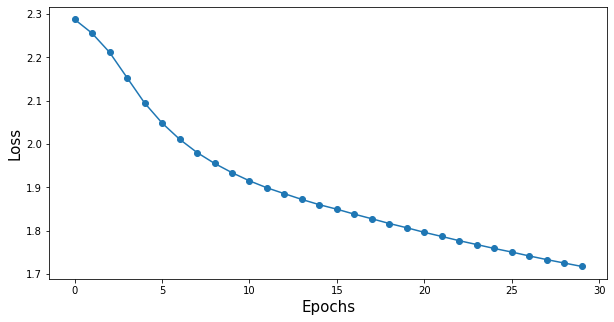

In [8]:
num_epochs = 30
plt.figure(figsize = (10, 5))
plt.scatter(range(num_epochs), loss_hist)
plt.plot(loss_hist)
plt.xlabel("Epochs",fontsize=15)
plt.ylabel("Loss",fontsize=15)

# Задание 2. Построение графиков

До этого выводился только Test loss.
Добавьте графики для:

* Train loss
* Train accuracy
* Test accuracy

Оба графика для Loss выводите в одних координатных осях.

Оба графика для Accuracy так же выводите в одних координатных осях.

In [9]:
def train1(model, criterion, optimizer, num1_epochs = 5, tag = "cifar10"):
    loss_train_hist=[]
    loss_test_hist=[]
    acc_train_hist=[]
    acc_test_hist=[]
    epochs = trange(num1_epochs)
    for epoch in epochs:

      ep_loss = 0
      for imgs, labels in train_loader:     
            
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        ep_loss += loss.item()

      val_loss = 0
      for imgs, labels in test_loader:     
            
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        
      accuracy = calaculate_accuracy(model, train_loader)
      acc_train_hist.append(accuracy)
      val_accuracy = calaculate_accuracy(model, test_loader)
      acc_test_hist.append(val_accuracy) 
      loss_test_hist.append(val_loss / ( len(test_loader) ))
      loss_train_hist.append(ep_loss / ( len(train_loader) ))
       
    return loss_train_hist, loss_test_hist, acc_train_hist, acc_test_hist

In [10]:
model = FCNet()
model.train()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()
loss_train_hist, loss_test_hist, acc_train_hist, acc_test_hist = train1(model, criterion, optimizer, num1_epochs = 30)

100%|██████████| 30/30 [14:18<00:00, 28.60s/it]


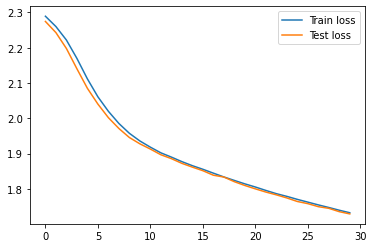

In [11]:
plt.plot(loss_train_hist)
plt.plot(loss_test_hist)
plt.legend(("Train loss","Test loss")) 

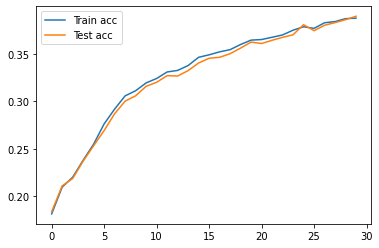

In [12]:
plt.plot(acc_train_hist)
plt.plot(acc_test_hist)
plt.legend(("Train acc","Test acc"))

#Задание 3. Нормализация данных

Нормализуйте данные.

* Подсчитайте среднее значение и стандартное отклонение для каждого из 3-х цветовых каналов 
 * Сделайте это с помощью встроенных в torch функций
* Нормализуйте данные с использованием этих параметров (используйте трансформацию Normalize)
* Оцените влияние нормировки данных на точность обучения. (Сравните результаты обучения на ненормированных данных и на нормированных)



In [13]:
import numpy as np
from torchvision import transforms
print(trainset.data.shape)
print(trainset.data[100][31][31])
mean = np.mean(trainset.data[:][:][:][0])
std = np.std(trainset.data[:][:][:][0])

mean = []
std = []
for i in [0, 1, 2]:
  mean += [np.mean(trainset.data[:][:][:][i])/255]
  std += [np.std(trainset.data[:][:][:][i])/255]
print(mean,std)

transform_with_norm = transforms.Compose([
                transforms.ToTensor(),
                torchvision.transforms.Normalize(mean, std)
            ])

trainset.transform = transform_with_norm 
testset.transform = transform_with_norm

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

(50000, 32, 32, 3)
[228 228 226]
[0.40567555147058826, 0.5111660028594771, 0.5244727839052288] [0.20381850341830213, 0.23717334049548047, 0.32377743379113044]


In [14]:
model = FCNet()  
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)  
criterion = nn.CrossEntropyLoss() 
loss_train_hist, loss_test_hist, acc_train_hist, acc_test_hist = train1(model, criterion, optimizer, num1_epochs = 30)

100%|██████████| 30/30 [18:04<00:00, 36.17s/it]


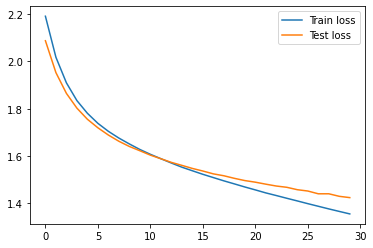

In [15]:
plt.plot(loss_train_hist)
plt.plot(loss_test_hist)
plt.legend(("Train loss","Test loss")) 

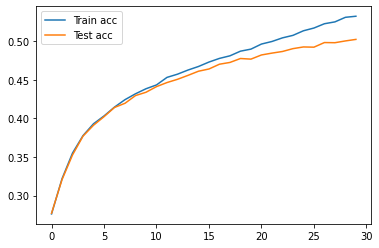

In [16]:
plt.plot(acc_train_hist)
plt.plot(acc_test_hist)
plt.legend(("Train acc","Test acc"))

На самом деле можно заметить существенное улучшение.

# Задание 4. Влияние функций активации

* Исследуйте влияние функций активации на скорость обучения и точность предсказаний модели.

* Используйте три функции:

 * [Sigmoid](https://pytorch.org/docs/stable/nn.functional.html#sigmoid)
 * [GELU](https://pytorch.org/docs/stable/nn.functional.html#gelu)
 * [ReLU](https://pytorch.org/docs/stable/nn.functional.html#relu)
* Постройте графики потерь loss для разных функций активации в одних осях.

* Можете модифировать конструктор класса сети, чтобы была возможность передать туда желаемую функцию активации.

In [17]:
from torch import nn

activation_functions = { 'sigmoid':nn.Sigmoid(), 'relu': nn.ReLU(), 'gelu' : nn.GELU()}

In [18]:
class FCNet(nn.Module):
    def __init__(self, activation_function):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512) 
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)
        self.activation_function = activation_function

    def forward(self, x):
        x = x.view(-1, 32*32*3) 
        x = self.fc1(x)
        x = self.activation_function(x)
        x = self.fc2(x)
        x = self.activation_function(x)
        x = self.fc3(x)
        return x

In [19]:
import torch

def train2(model, criterion, optimizer, num1_epochs = 20, tag = "cifar10"):
  loss_K = []
  epochs = trange(num1_epochs)
  for epoch in epochs:
      ep_loss = 0
      for imgs, labels in train_loader:     
          
          outputs = model(imgs)
          loss = criterion(outputs, labels)
          loss.backward()
          ep_loss += loss.item()
          optimizer.step()
          optimizer.zero_grad()

      loss_K.append(ep_loss / ( len(train_loader) ))
  accuracy = calaculate_accuracy(model, test_loader)
  return accuracy, loss_K

100%|██████████| 30/30 [08:22<00:00, 16.76s/it]


sigmoid 0.2967


100%|██████████| 30/30 [08:26<00:00, 16.90s/it]


relu 0.5033


100%|██████████| 30/30 [08:32<00:00, 17.09s/it]


gelu 0.501


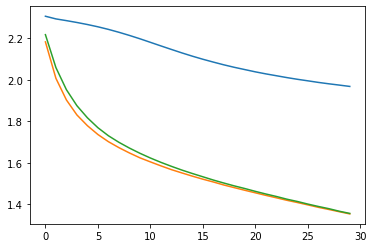

In [20]:
for i in activation_functions:
  model = FCNet(activation_functions[i])  
  optimizer = torch.optim.SGD(model.parameters(), lr=0.005)
  criterion = nn.CrossEntropyLoss() 
  accuracy, loss_K = train2(model, criterion, optimizer, num1_epochs = 30, tag = i)
  plt.plot(loss_K)
  print(i, accuracy)

relu победила, хотя gelu отстала не сильно

# Задание 5. Реализация ReLU

* Самостоятельно реализуйте функцию активации ReLU. (Методами torch)
* Замените в уже обученной модели функцию активации на вашу.

Убедитесь, что точность обученной модели не изменилась.




In [21]:
class CustomReLU(nn.Module):     
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512) 
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)   

    def forward(self, x): 
        x = x.view(-1, 32*32*3) 
        x = self.fc1(x)
        x = torch.max(x, torch.zeros(512))
        x = self.fc2(x)
        x = torch.max(x, torch.zeros(128))
        x = self.fc3(x)
        return x

In [22]:
model = CustomReLU()  
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)  
train2(model, nn.CrossEntropyLoss(), optimizer, num1_epochs = 30)

100%|██████████| 30/30 [08:30<00:00, 17.02s/it]


(0.5027,
 [2.198771005990554,
  2.012233643507471,
  1.8956609319667428,
  1.8193810795034682,
  1.763454558289781,
  1.7217129006677745,
  1.6893073922517348,
  1.6613200720475645,
  1.6364858789103371,
  1.6153819956341569,
  1.5962490986804574,
  1.5769192661557878,
  1.559633416180708,
  1.5433213771605978,
  1.5266734185267468,
  1.5129378754265455,
  1.4986281948430198,
  1.4842812698714587,
  1.4711776868421205,
  1.4592527826221622,
  1.446197353455485,
  1.433659286523352,
  1.4223510580403464,
  1.409211094890322,
  1.39793484551566,
  1.3860777543515574,
  1.375396590451805,
  1.3634578159877233,
  1.3534200939596917,
  1.3416798017462905])

Не изменилась

# Задание 6. Замените функцию потерь

* Замените функцию потерь. Вместо [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html?highlight=cross%20entropy%20loss#crossentropyloss) используйте [NLLLoss](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html?highlight=nllloss#nllloss) (Подумайте в чём разница)

* Убедитесь, что результаты не поменялись. Если возникнет необходимость, внесите изменения в код модели используйте наследование.

In [23]:
def train3(model, optimizer, num1_epochs = 20, tag = "cifar10"):
  loss_P = []
  epochs = trange(num1_epochs)
  for epoch in epochs:
      ep_loss = 0
      for imgs, labels in train_loader:     
          
          outputs = model(imgs)

          D1 = nn.LogSoftmax()
          S1 = nn.NLLLoss()

          loss = S1(D1(outputs), labels)
          loss.backward()
          ep_loss += loss.item()
          optimizer.step()
          optimizer.zero_grad()

      loss_P.append(ep_loss / ( len(train_loader) ))
  accuracy = calaculate_accuracy(model, test_loader)
  return accuracy, loss_P

In [24]:
model = CustomReLU()  
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)  
train3(model, optimizer, num1_epochs = 30)

  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  del sys.path[0]
100%|██████████| 30/30 [08:46<00:00, 17.55s/it]


(0.5038,
 [2.184835352459732,
  2.0103968460949098,
  1.9028986053807395,
  1.8262093286125027,
  1.7700923468385423,
  1.7271273476736886,
  1.6936350087730252,
  1.66457949061783,
  1.6401040353337113,
  1.6190842463045705,
  1.598233552611604,
  1.579971554936195,
  1.5626749286846238,
  1.54636570203061,
  1.5318105962811683,
  1.5155898277856865,
  1.5025500801144813,
  1.4881770896668336,
  1.474347831035147,
  1.4624157937205569,
  1.4498380386099523,
  1.4368262546403068,
  1.4251170511148414,
  1.4141093717545878,
  1.4022602347695097,
  1.390837412099449,
  1.3790306418525928,
  1.368565243725874,
  1.3560128558655173,
  1.345607996595149])

nn.CrossEntropyLoss() объединяет nn.LogSoftmax()( log(softmax(x))) и nn.NLLLoss()в одном классе. Ну и получилось в итоге тоже самое.

Думаю у меня прям много неоптимального в этом задании, но помоему в этот раз было действительно сложнее чем в предыдущие занятия.